In [1]:
import sys
import pandas as pd
import glob
import numpy as np
import os
import pickle
import scipy as scp
import seaborn as sns 
import matplotlib.pyplot as plt
sys.path.append("/home/adityamoger/Documents/GitHub/dynamic_model_of_cocktail_party_nightmare/dynamic_model/")

from scores.collision_scores import compute_collision_counts_and_length
from scores.run_all_score_calculations import filter_bat_positions_from_history
from supporting_files.utilities import load_history_dump, load_parameters

In [ ]:
# group_sizes

with open("/home/adityamoger/Documents/GitHub/dynamic_model_of_cocktail_party_nightmare/group_size_100_condensed_data_whole.pickle", "rb") as f:
    store_scores = pickle.load(f)

# x= []
# # x.extend(store_scores[100][1])
# x.extend(store_scores[0][1])
# len(x)
# store_scores

[('experiment_type',
  'group_size',
  'iteration',
  'collision_counts',
  'wall_collision_counts',
  'bat_bat_collision_counts',
  'duration',
  'consistency_type'),
 ('positive_control', 5, np.int64(0), 59, 34, 25, 30.0, '3/5'),
 ('positive_control', 5, np.int64(0), 67, 21, 46, 30.0, '2/3'),
 ('positive_control', 5, np.int64(1), 55, 28, 27, 30.0, '3/5'),
 ('positive_control', 5, np.int64(1), 51, 15, 36, 30.0, '2/3'),
 ('positive_control', 5, np.int64(2), 68, 36, 32, 30.0, '3/5'),
 ('positive_control', 5, np.int64(2), 60, 19, 41, 30.0, '2/3'),
 ('positive_control', 5, np.int64(3), 58, 27, 31, 30.0, '3/5'),
 ('positive_control', 5, np.int64(3), 47, 13, 34, 30.0, '2/3'),
 ('positive_control', 5, np.int64(4), 56, 27, 29, 30.0, '3/5'),
 ('positive_control', 5, np.int64(4), 67, 22, 45, 30.0, '2/3'),
 ('positive_control', 5, np.int64(5), 54, 27, 27, 30.0, '3/5'),
 ('positive_control', 5, np.int64(5), 49, 18, 31, 30.0, '2/3'),
 ('positive_control', 5, np.int64(6), 66, 30, 36, 30.0, '3/5'),


In [3]:
raw_df = pd.DataFrame(store_scores[1:], columns= store_scores[0])
raw_df= raw_df[raw_df["duration"]==30]
raw_df = raw_df[raw_df["consistency_type"]=="3/5"]

In [4]:
big_output_dir = "/media/adityamoger/T7 Shield/BACKUP_THESIS_DATA"
treatment_dir = big_output_dir + "/*_treatment"
null_dir = big_output_dir + "/*_null"
consistency_types = ["3/5", "2/3"]
experiment_types = ["positive_control", "negative_control", "treatment", "null"]
group_sizes = [5, 10, 30, 50, 75, 100]
iterations = np.arange(0, 20, 1)

store_individual_scores_labels = [
    (
        "experiment_type",
        "group_size",
        "iteration",
        "collision_counts",
        "wall_collision_counts",
        "bat_bat_collision_counts",
        "duration",
        "consistency_type",
        "bat_id",
    )
]



In [ ]:
df = pd.DataFrame(store_scores[1:], columns= store_scores[0])
df= df[df["duration"]==30]


<Axes: xlabel='duration', ylabel='Count'>

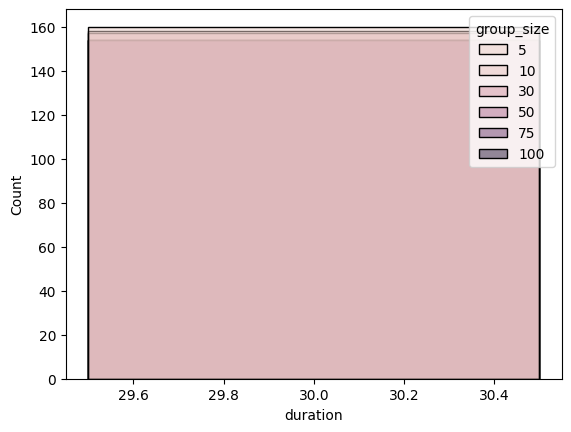

In [6]:
sns.histplot(df, x="duration",hue="group_size")

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [8]:
df.keys()

Index(['experiment_type', 'group_size', 'iteration', 'collision_counts',
       'wall_collision_counts', 'bat_bat_collision_counts', 'duration',
       'consistency_type'],
      dtype='object')

<Axes: xlabel='group_size', ylabel='collision_counts'>

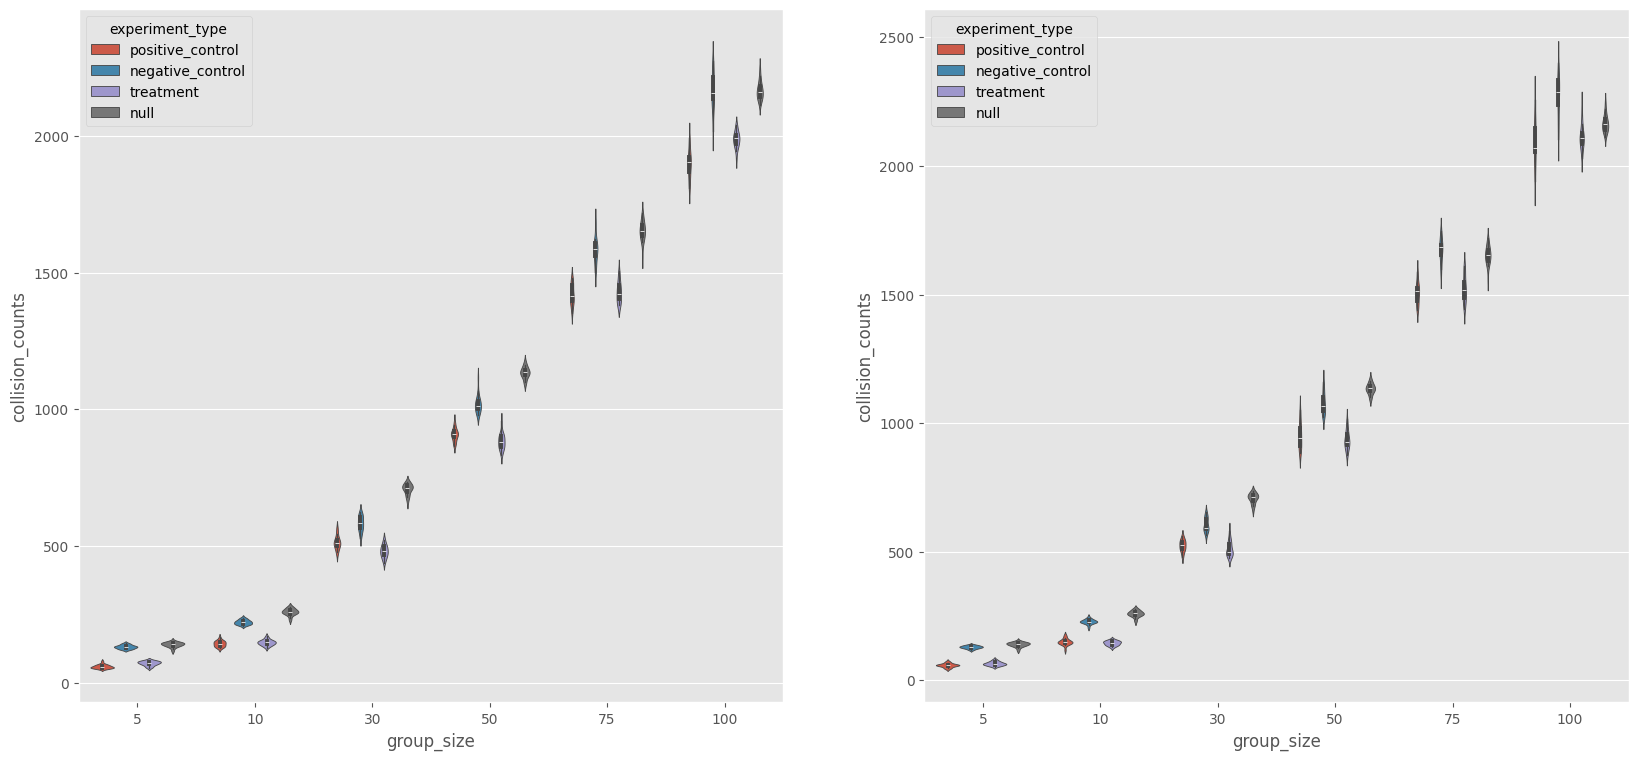

In [9]:
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
sns.violinplot(df[df["consistency_type"]=="3/5"], x="group_size", y="collision_counts", hue="experiment_type")
plt.subplot(1,2,2)
sns.violinplot(df[df["consistency_type"]=="2/3"], x="group_size", y="collision_counts", hue="experiment_type")

<Axes: xlabel='group_size', ylabel='bat_bat_collision_counts'>

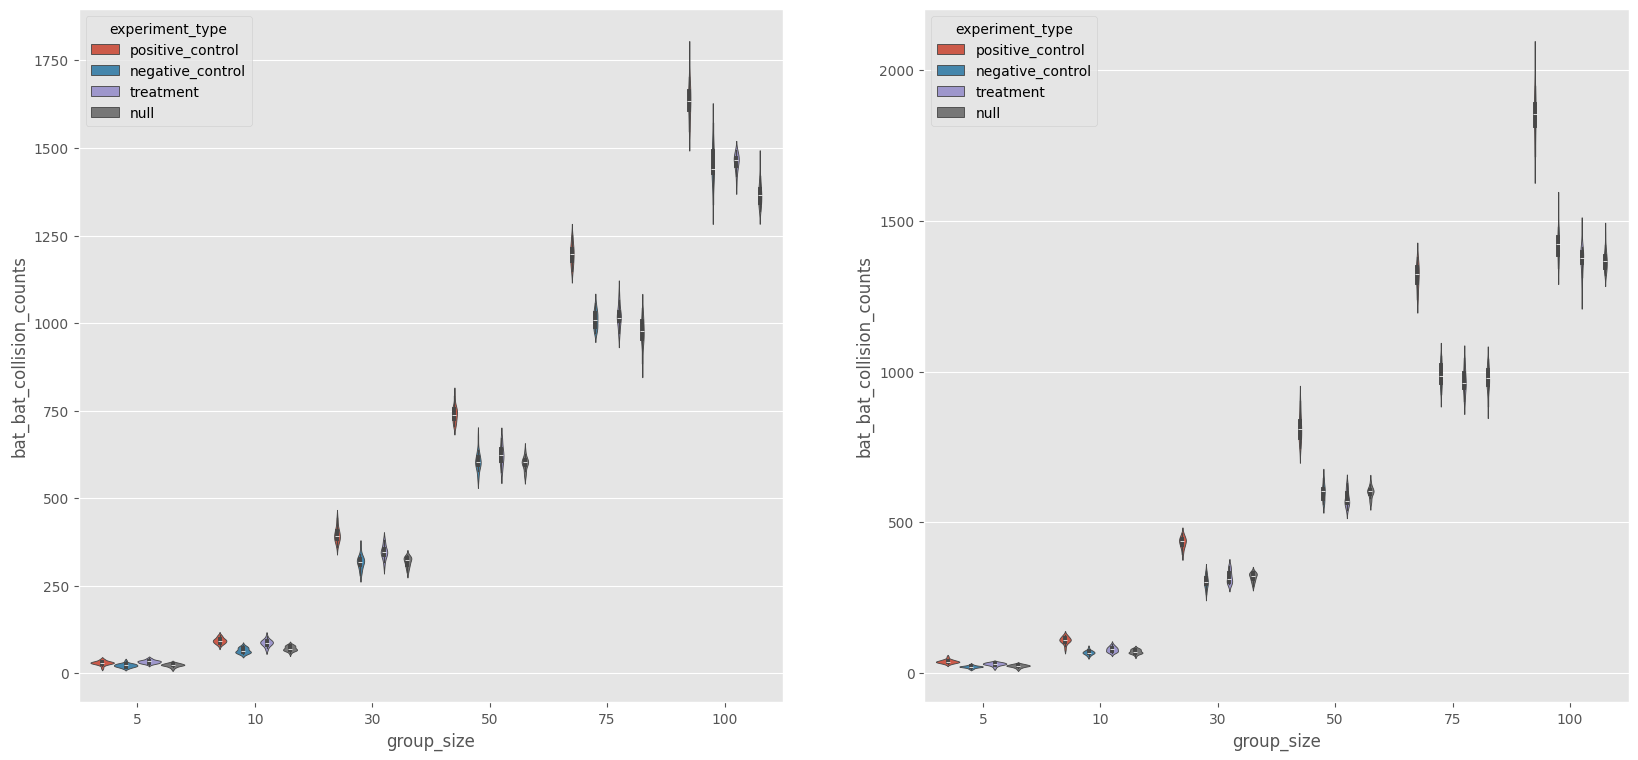

In [10]:
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
sns.violinplot(df[df["consistency_type"]=="3/5"], x="group_size", y="bat_bat_collision_counts", hue="experiment_type")
# plt.ylim(0,1600)
plt.subplot(1,2,2)
sns.violinplot(df[df["consistency_type"]=="2/3"], x="group_size", y="bat_bat_collision_counts", hue="experiment_type")
# plt.ylim(0,1600)

<Axes: xlabel='group_size', ylabel='wall_collision_counts'>

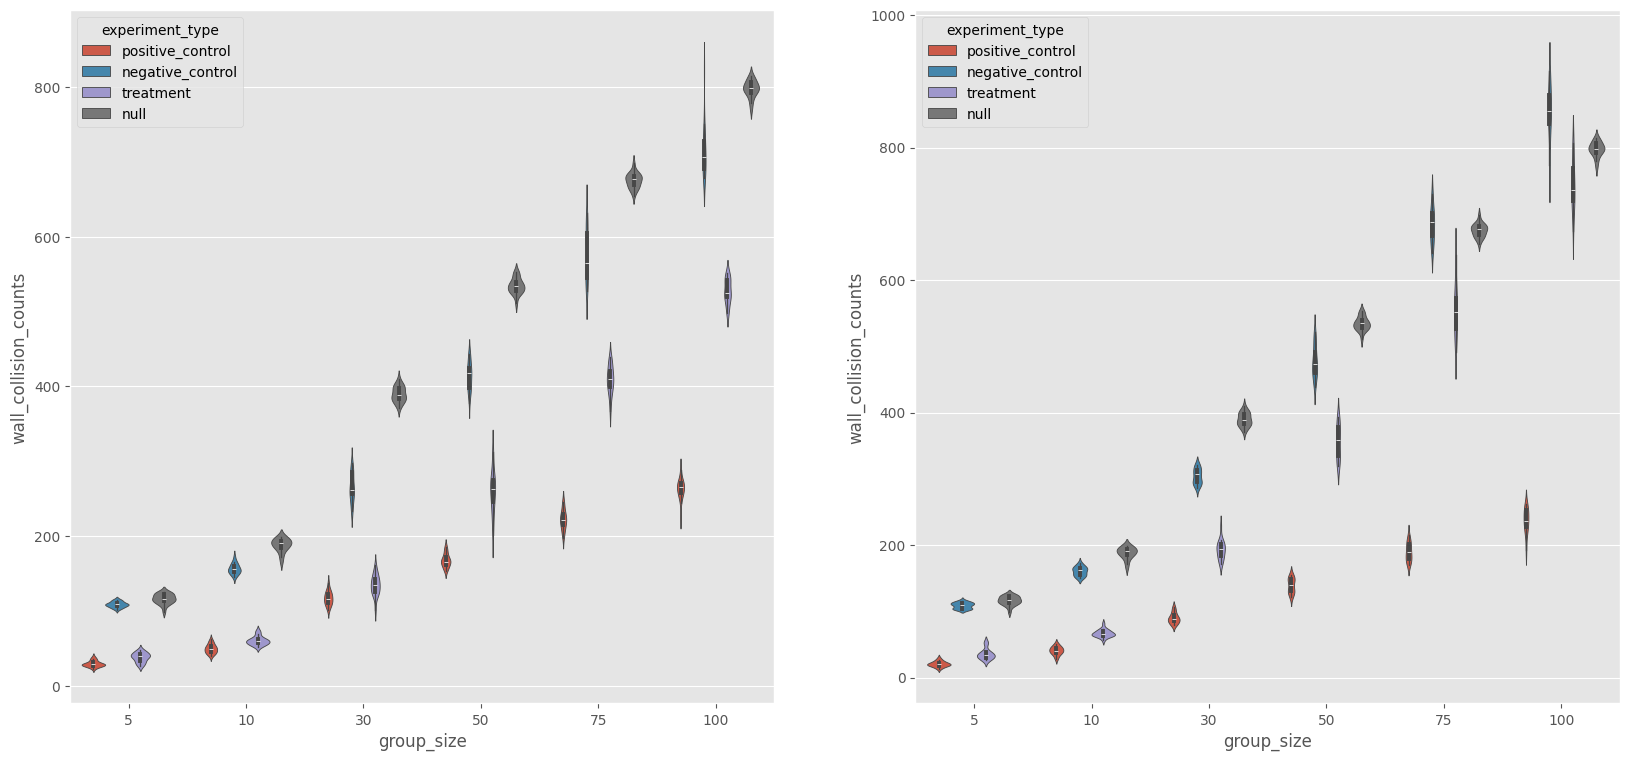

In [11]:
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
sns.violinplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_counts", hue="experiment_type")
plt.subplot(1,2,2)
sns.violinplot(df[df["consistency_type"]=="2/3"], x="group_size", y="wall_collision_counts", hue="experiment_type")

<Axes: ylabel='wall_collision_counts'>

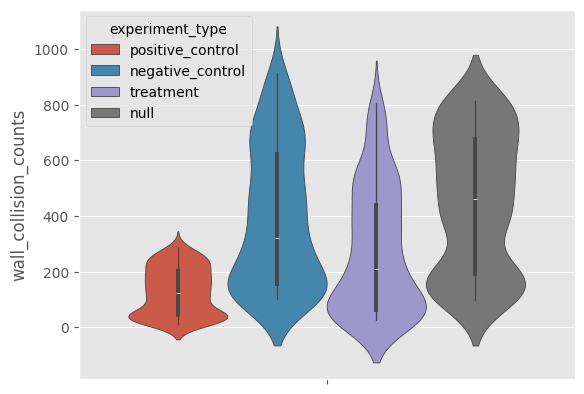

In [12]:
sns.violinplot(df, y="wall_collision_counts", hue="experiment_type")

<Axes: xlabel='group_size', ylabel='bat_bat_collision_counts'>

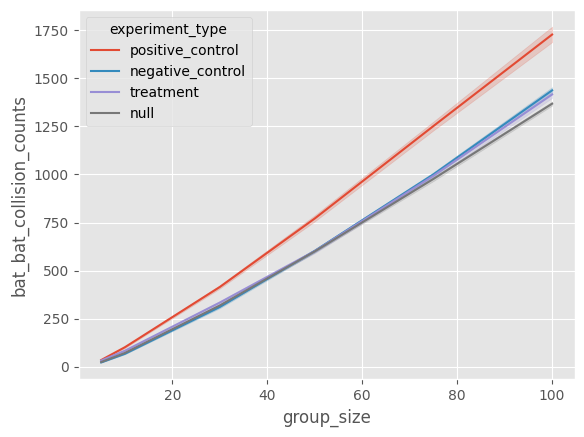

In [13]:
sns.lineplot(df, x="group_size", y="bat_bat_collision_counts", hue="experiment_type")

<Axes: xlabel='group_size', ylabel='collision_counts'>

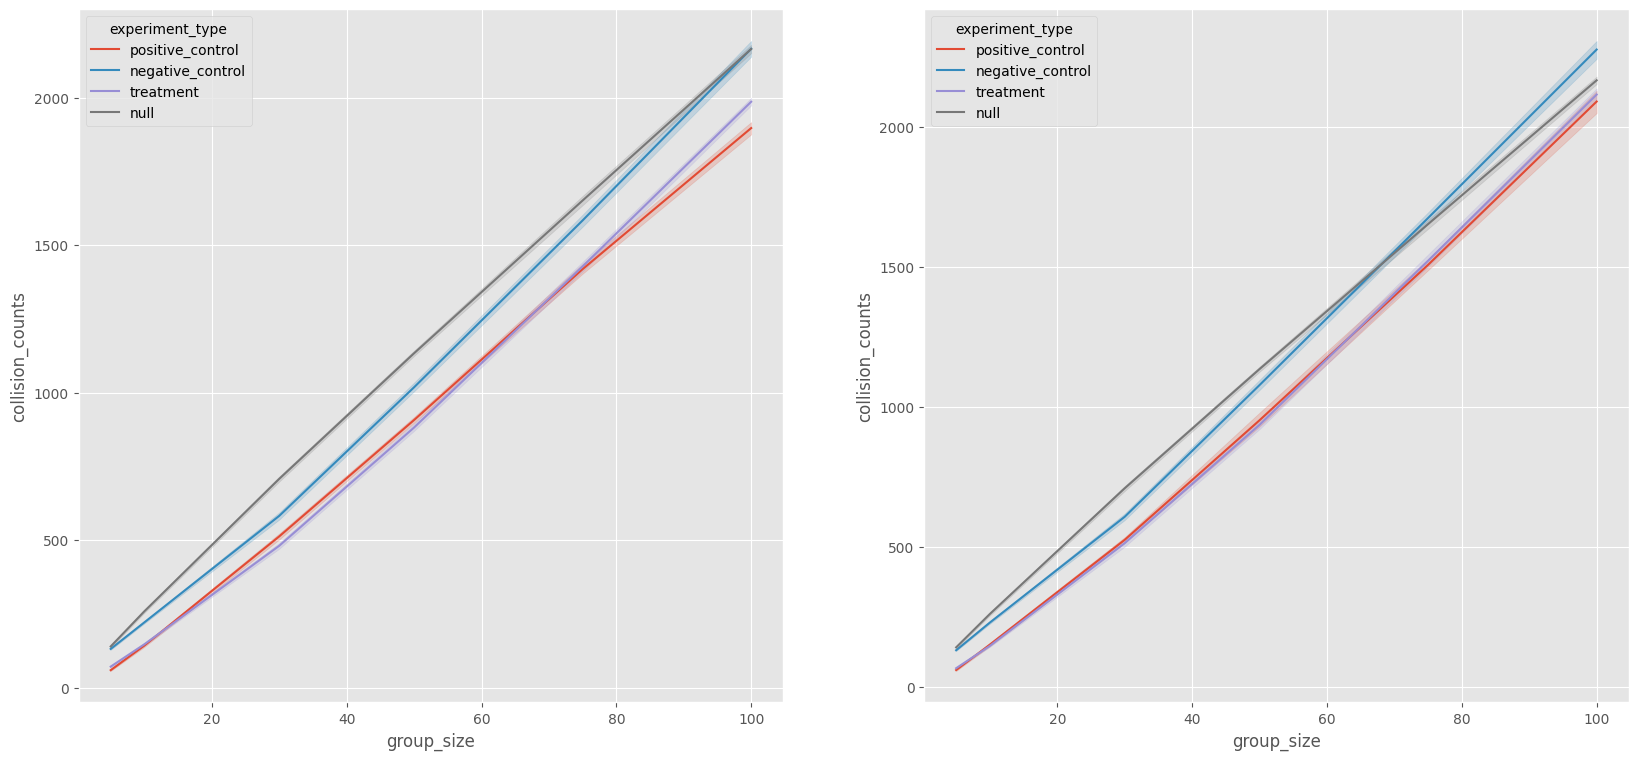

In [14]:
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="collision_counts", hue="experiment_type")
# plt.ylim(0,40)
plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="2/3"], x="group_size", y="collision_counts", hue="experiment_type")
# plt.ylim(0,40)

<Axes: xlabel='group_size', ylabel='bat_bat_collision_counts'>

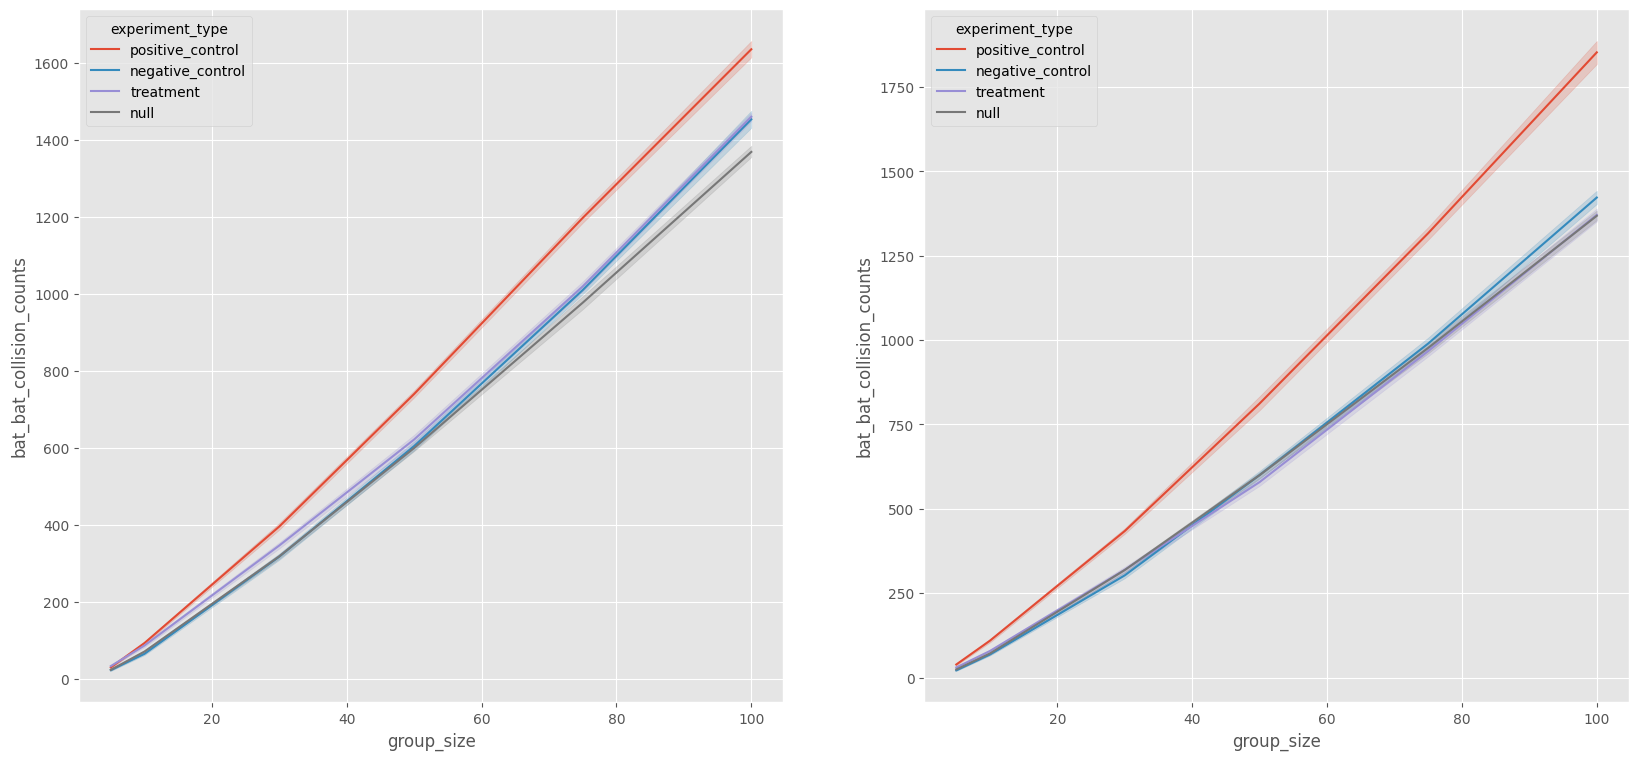

In [15]:
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="bat_bat_collision_counts", hue="experiment_type")
# plt.ylim(0,38)
plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="2/3"], x="group_size", y="bat_bat_collision_counts", hue="experiment_type")
# plt.ylim(0,38)

<Axes: xlabel='group_size', ylabel='wall_collision_counts'>

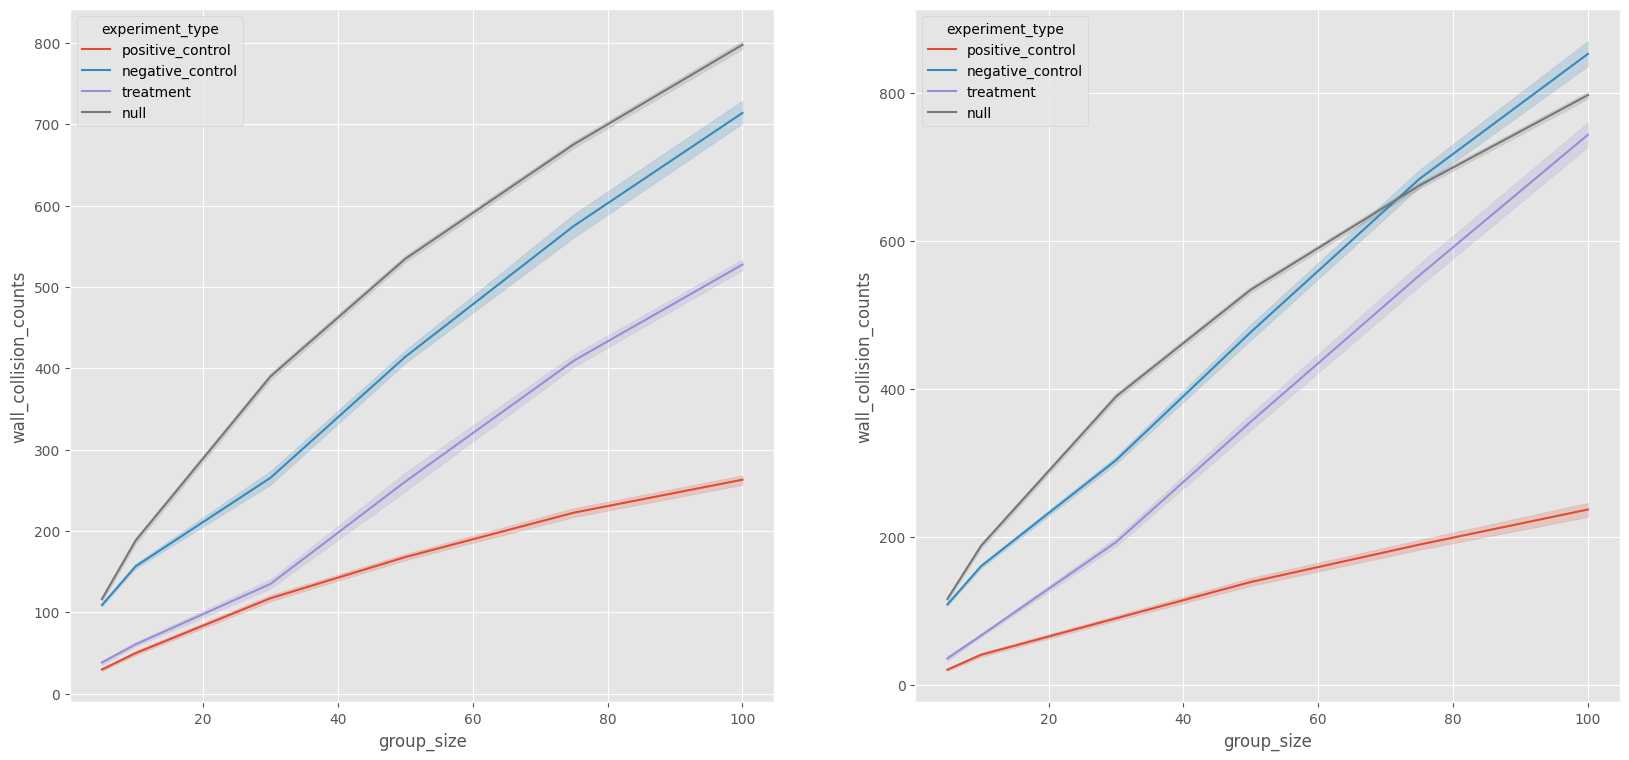

In [16]:
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_counts", hue="experiment_type")
plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="2/3"], x="group_size", y="wall_collision_counts", hue="experiment_type")

In [17]:
df["collision_counts_scaled"] = df["collision_counts"]/(df["group_size"])
df["wall_collision_counts_scaled"] = df["wall_collision_counts"]/df["group_size"]
df["bat_bat_collision_counts_scaled"] = df["bat_bat_collision_counts"]/df["group_size"]

<Axes: xlabel='group_size', ylabel='collision_counts_scaled'>

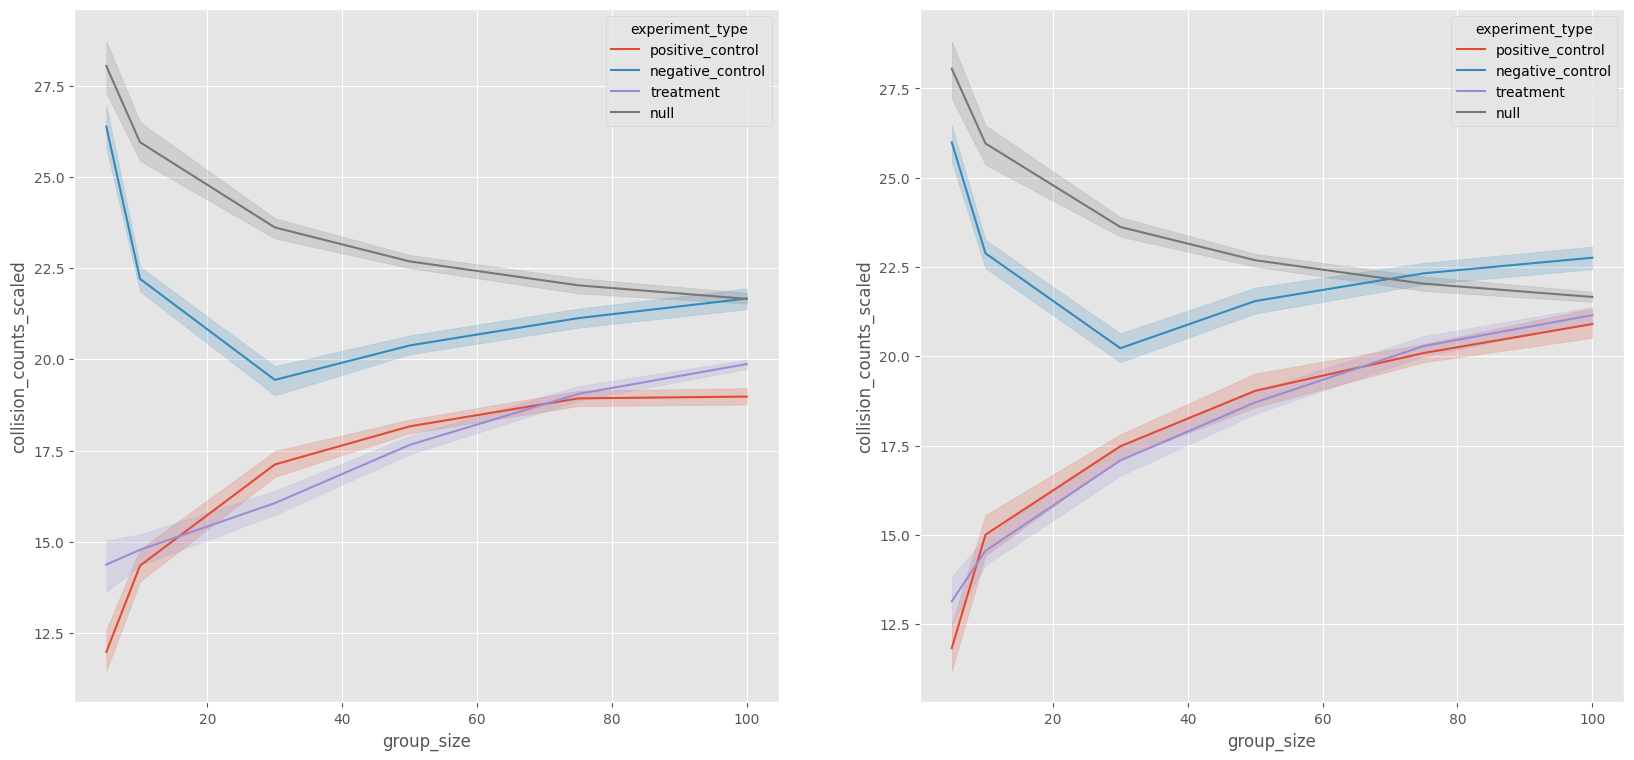

In [18]:
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="collision_counts_scaled", hue="experiment_type")
plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="2/3"], x="group_size", y="collision_counts_scaled", hue="experiment_type")

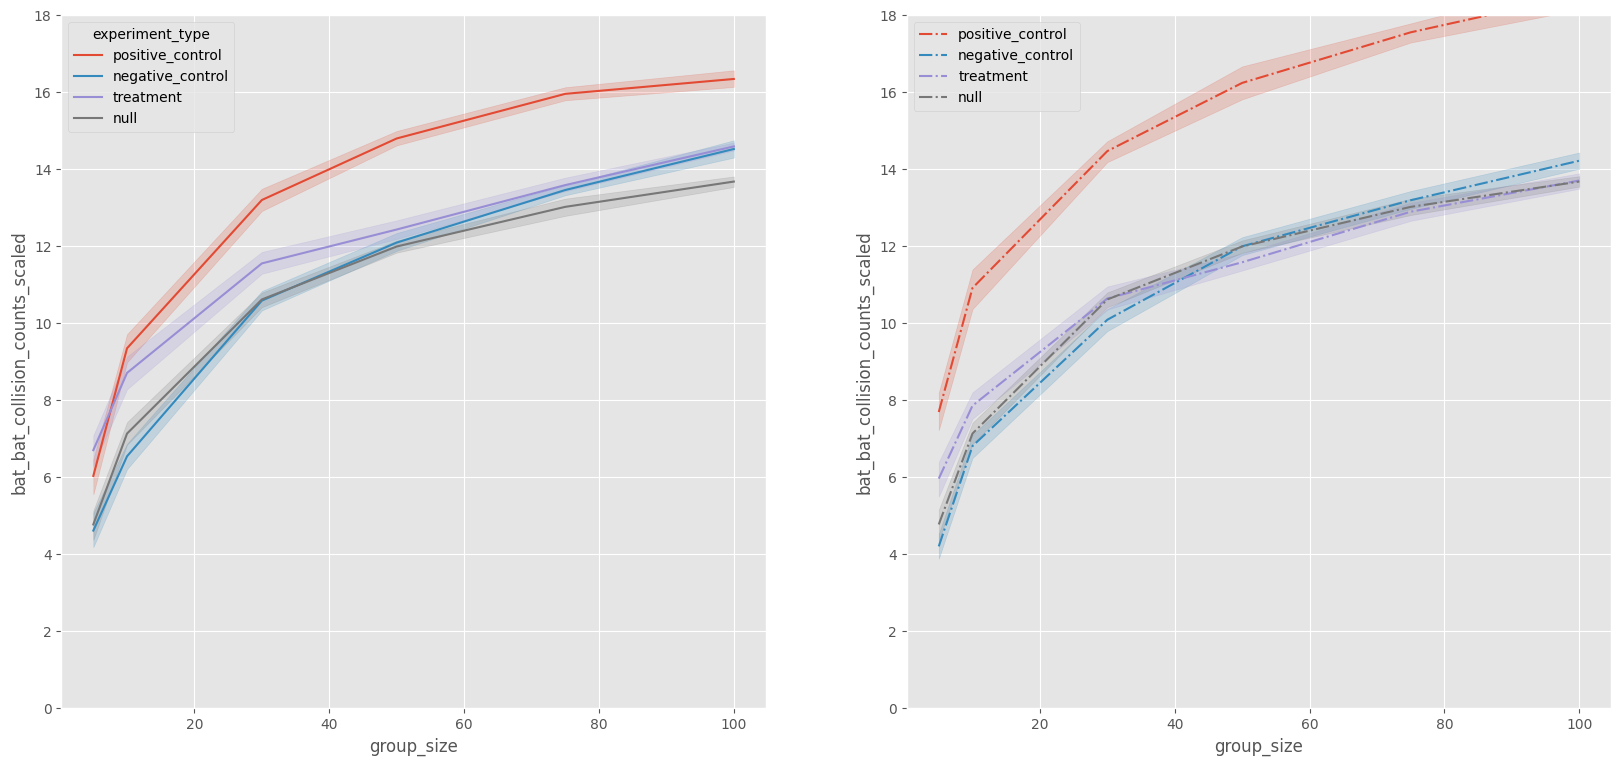

In [19]:
plt.figure(figsize=(20,9))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="bat_bat_collision_counts_scaled", hue="experiment_type")
plt.ylim(0,18)
plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="2/3"], x="group_size", y="bat_bat_collision_counts_scaled", hue="experiment_type", ls="-.")
plt.ylim(0,18)
plt.legend()

<Axes: xlabel='group_size', ylabel='wall_collision_scaled_time_and_size'>

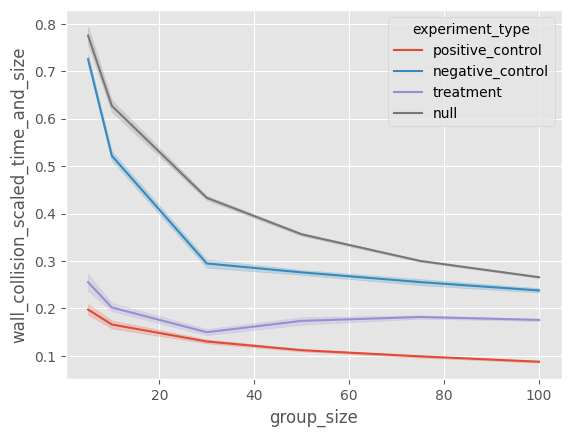

In [20]:
df["collision_scaled_time_and_size"] = df["collision_counts"]/(df["group_size"]*30)
df["wall_collision_scaled_time_and_size"] = df["wall_collision_counts"]/(df["group_size"]*30)
df["bat_bat_collision_scaled_time_and_size"] = df["bat_bat_collision_counts"]/(df["group_size"]*30)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_scaled_time_and_size", hue="experiment_type")

In [21]:
df_tr = df.loc[(df["experiment_type"]=="treatment")&(df["consistency_type"]=="3/5")].reset_index()
df_nu = df.loc[(df["experiment_type"]=="null")&(df["consistency_type"]=="3/5")].reset_index()
df_nc = df.loc[(df["experiment_type"]=="negative_control")&(df["consistency_type"]=="3/5")].reset_index()
df_pc = df.loc[(df["experiment_type"]=="positive_control")&(df["consistency_type"]=="3/5")].reset_index()
# plt.plot(df_tr["collision_counts"].values - df_pc["collision_counts"].values)
pc_group_by = df_pc.groupby("group_size")
tr_group_by = df_tr.groupby("group_size")
nc_group_by = df_nc.groupby("group_size")
nu_group_by = df_nu.groupby("group_size")
# 
df_model_performance = pd.DataFrame(columns=df_pc.keys())
for group_size in group_sizes:
    tr = tr_group_by.get_group(group_size).mean(axis=0, numeric_only=True)
    # print(tr["wall_collision_counts_scaled"])
    pc = pc_group_by.get_group(group_size).mean(axis=0, numeric_only=True)
    # print(pc["wall_collision_counts_scaled"])
    nc = nc_group_by.get_group(group_size).mean(axis=0, numeric_only=True)
    nu = nu_group_by.get_group(group_size).mean(axis=0, numeric_only=True)
    
    model_performance = ((tr-pc)/nu)
    print(group_size, model_performance["collision_counts"])
    # df_model_performance = pd.concat((df_model_performance, ))
# df_model_performance
# pd.DataFrame(model_performance, columns=list(df_pc.keys().values)[2:])
# print(list(df_pc.keys())[2:])


5 0.08556149732620316
10 0.01675654853620953
30 -0.044874056304240476
50 -0.022432789775231318
75 0.00553706505295013
100 0.041224263687563455


In [22]:
import numpy as np
from scipy import stats
for group_size in group_sizes:
    tr_subset = tr_group_by.get_group(group_size)
    pc_subset = pc_group_by.get_group(group_size)
    ttstats = stats.ttest_ind(tr_subset["collision_counts"], pc_subset["collision_counts"])
    print(ttstats)

TtestResult(statistic=np.float64(5.0483203774627485), pvalue=np.float64(1.1415360043730976e-05), df=np.float64(38.0))
TtestResult(statistic=np.float64(1.315268898577423), pvalue=np.float64(0.196301087924614), df=np.float64(38.0))
TtestResult(statistic=np.float64(-4.202786980221328), pvalue=np.float64(0.00015401557068508656), df=np.float64(38.0))
TtestResult(statistic=np.float64(-3.1215741651402857), pvalue=np.float64(0.0034303951750663513), df=np.float64(38.0))
TtestResult(statistic=np.float64(0.7683484087047984), pvalue=np.float64(0.4470291474092868), df=np.float64(38.0))
TtestResult(statistic=np.float64(6.792272701178501), pvalue=np.float64(4.7038619655427004e-08), df=np.float64(38.0))


<Axes: xlabel='group_size', ylabel='wall_collision_counts_scaled'>

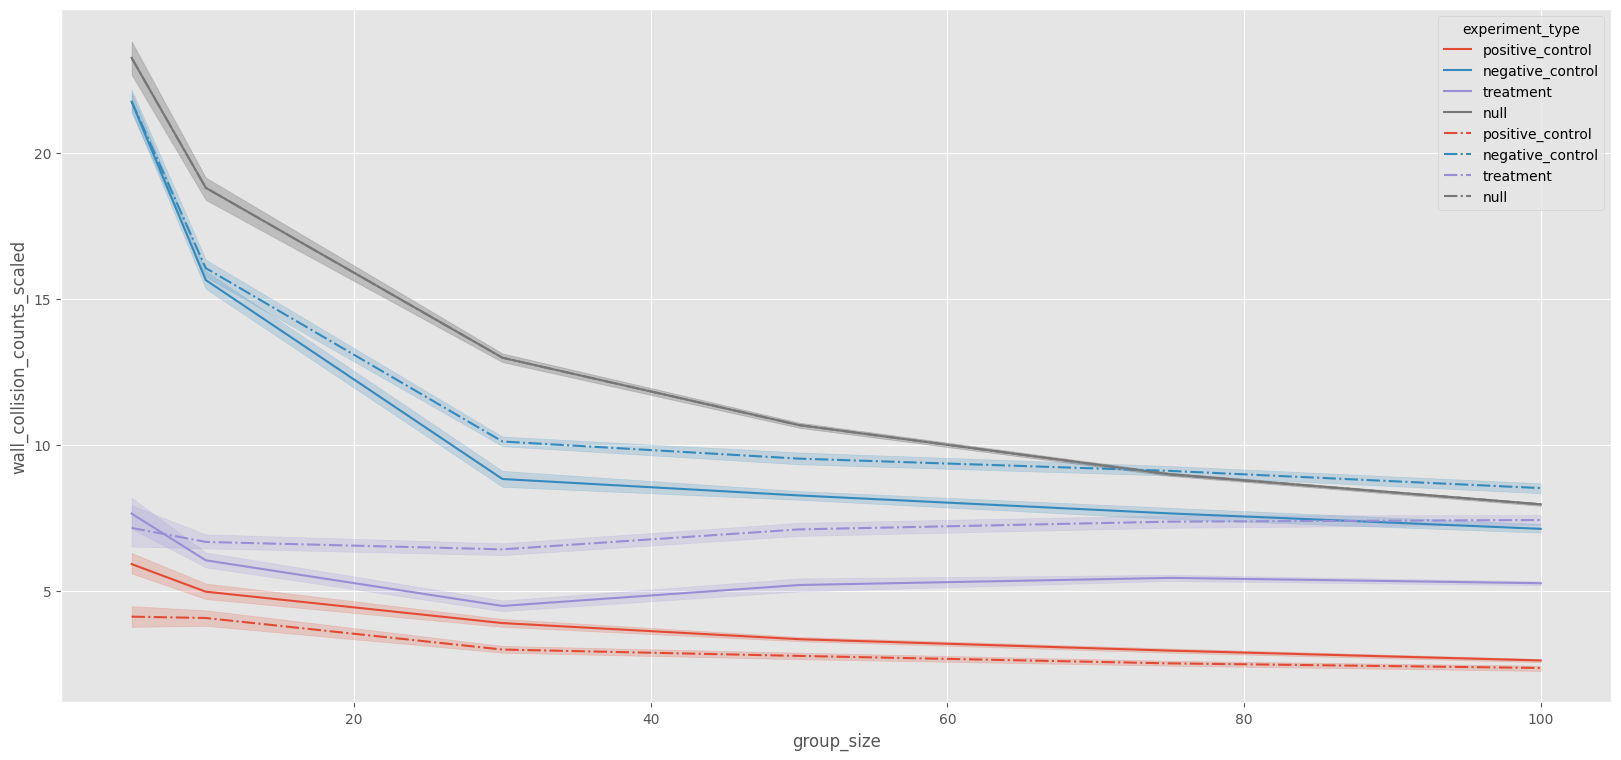

In [23]:
plt.figure(figsize=(20,9))
# plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_counts_scaled", hue="experiment_type")
# plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="2/3"], x="group_size", y="wall_collision_counts_scaled", hue="experiment_type", ls="-.")

In [24]:
sns.lineplot(df_copy[~(df_copy["group_size"]==200)], x="group_size", y="collision_counts_scaled", hue="experiment_type")
plt.ylabel("collision_counts / group_size")

NameError: name 'df_copy' is not defined

Text(0, 0.5, 'wall_collision_counts / group_size')

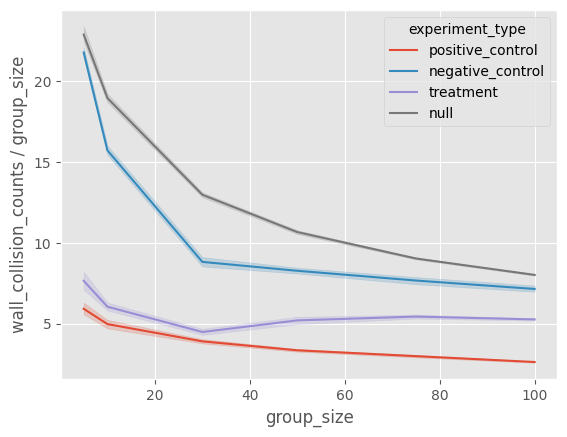

In [ ]:
sns.lineplot(df_copy[~(df_copy["group_size"]==200)], x="group_size", y="wall_collision_counts_scaled", hue="experiment_type")
plt.ylabel("wall_collision_counts / group_size")

Text(0, 0.5, 'bat bat collision_counts / group_size')

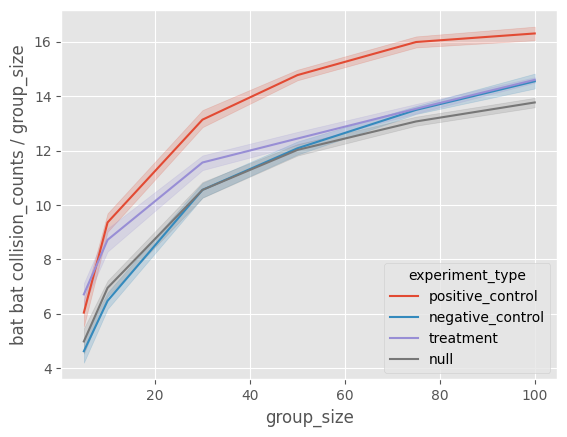

In [ ]:
sns.lineplot(df_copy[~(df_copy["group_size"]==200)], x="group_size", y="bat_bat_collision_counts_scaled", hue="experiment_type")
plt.ylabel("bat bat collision_counts / group_size")

<Axes: xlabel='group_size', ylabel='collision_counts'>

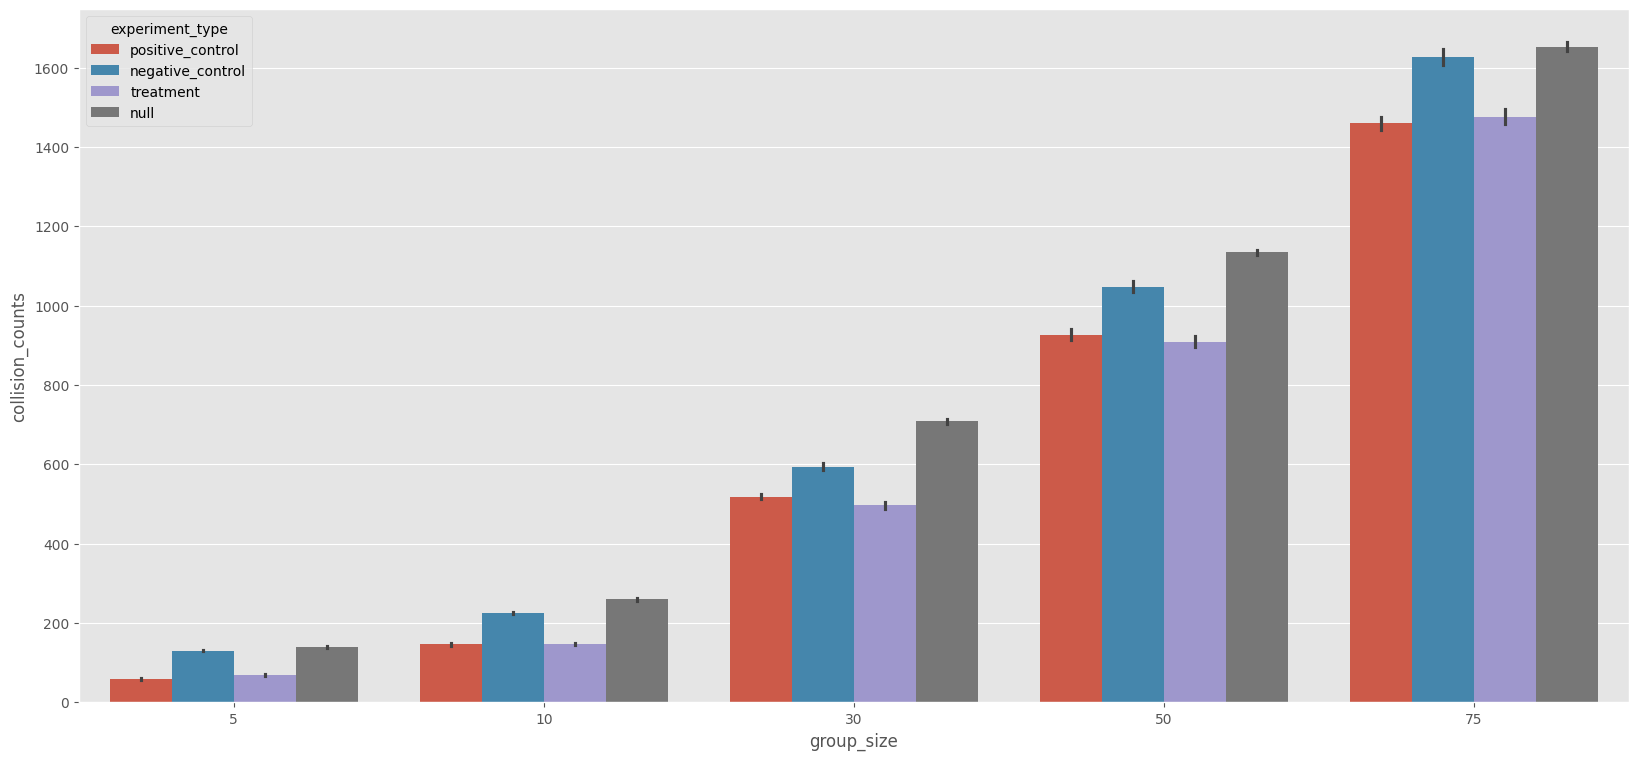

In [ ]:
plt.figure(figsize=(20,9))
# plt.subplot(1,3,1)
sns.barplot(df, y="collision_counts", hue="experiment_type", x="group_size")

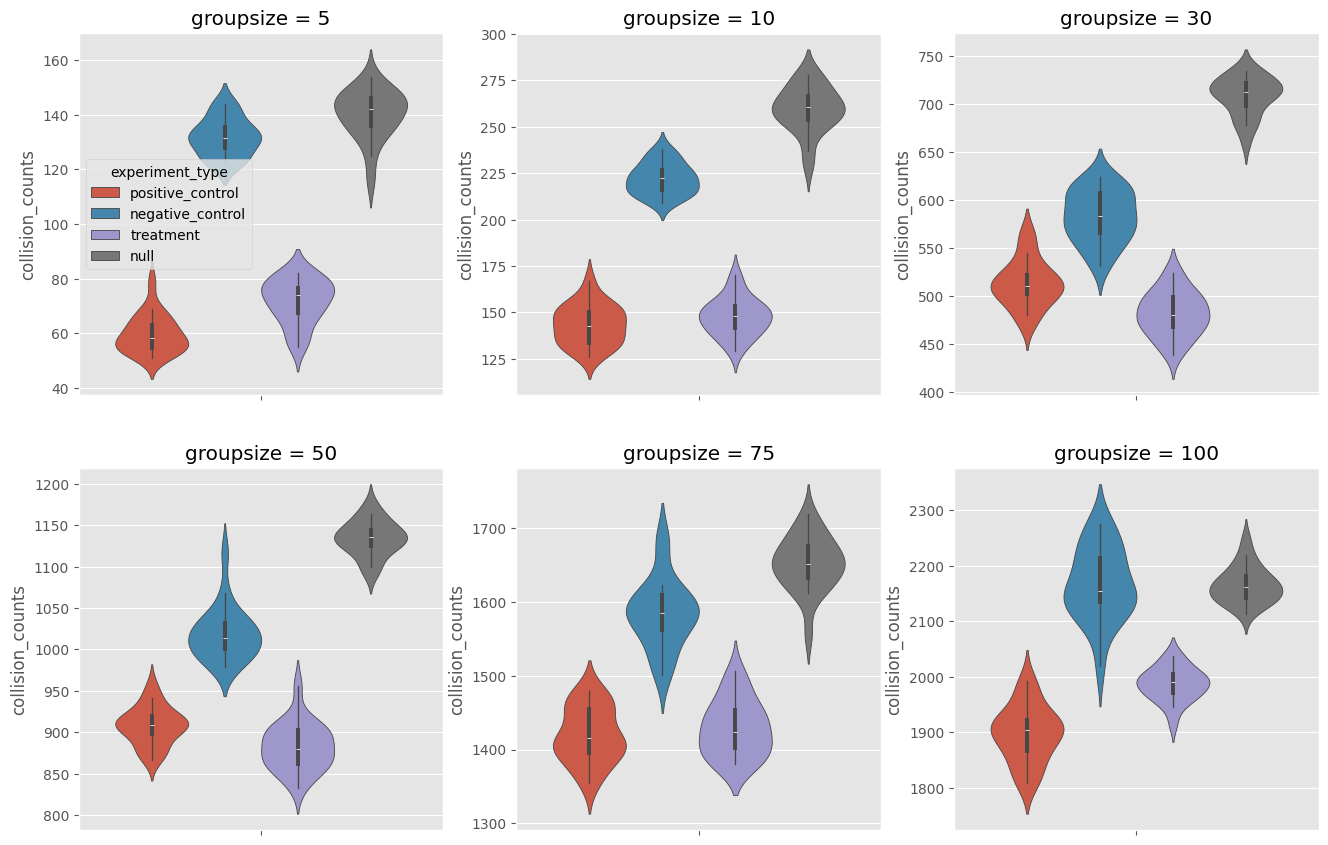

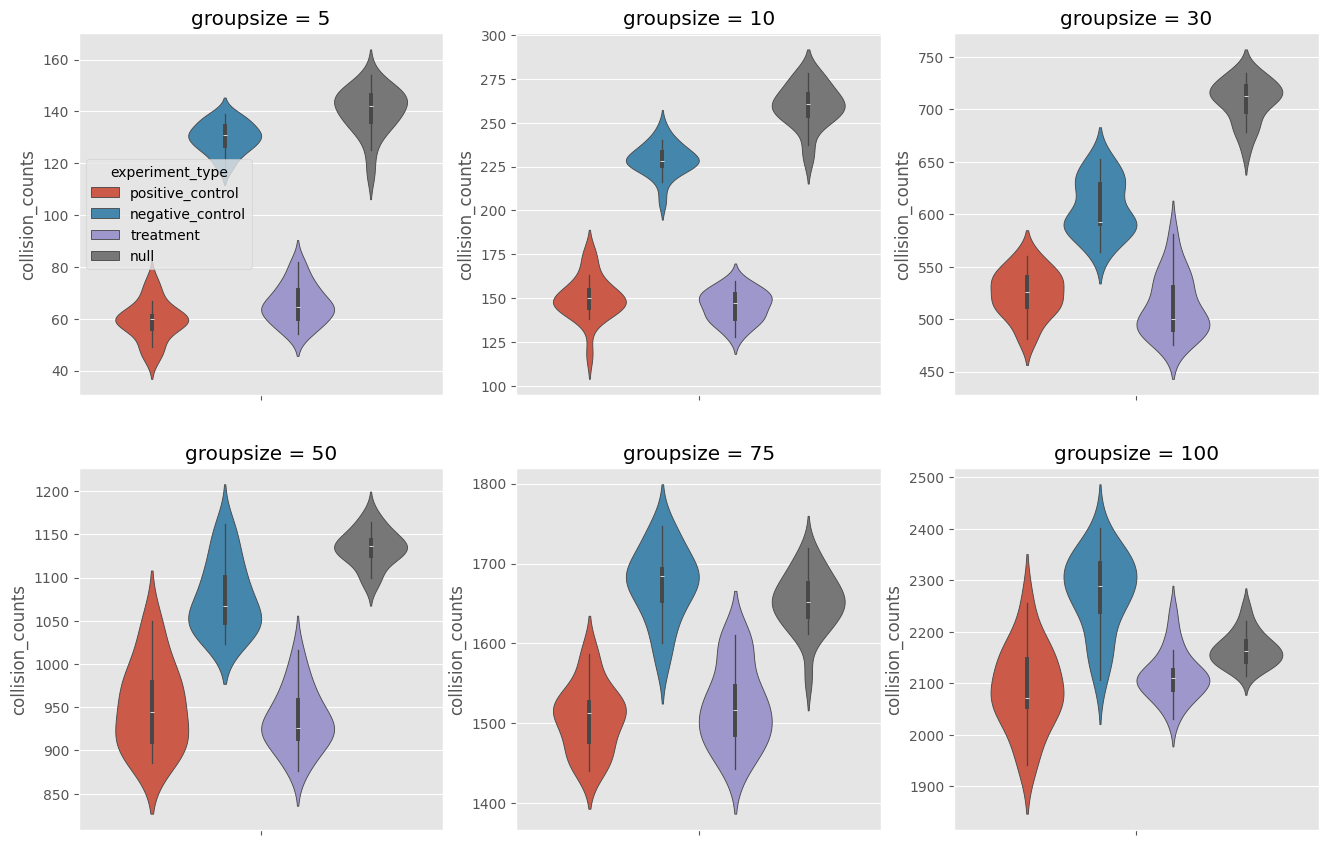

In [ ]:
plt.figure(figsize=(16,16))
group_sizes= [5,10,30,50,75,100]
for i, group_size in enumerate(group_sizes):
    subset_df = df.loc[(df["group_size"]==group_size) & (df["consistency_type"]=="3/5")]
    plt.subplot(3,3,i+1)
    legend = True if i==0 else False
    sns.violinplot(data=subset_df, hue="experiment_type", y= "collision_counts", legend=legend)
    # plt.ylim(0,30)
    plt.title(f"groupsize = {group_size}")
    
plt.figure(figsize=(16,16))
group_sizes= [5,10,30,50,75,100]
for i, group_size in enumerate(group_sizes):
    subset_df = df.loc[(df["group_size"]==group_size) & (df["consistency_type"]=="2/3")]
    plt.subplot(3,3,i+1)
    legend = True if i==0 else False
    sns.violinplot(data=subset_df, hue="experiment_type", y= "collision_counts", legend=legend)
    # plt.ylim(0,30)
    plt.title(f"groupsize = {group_size}")

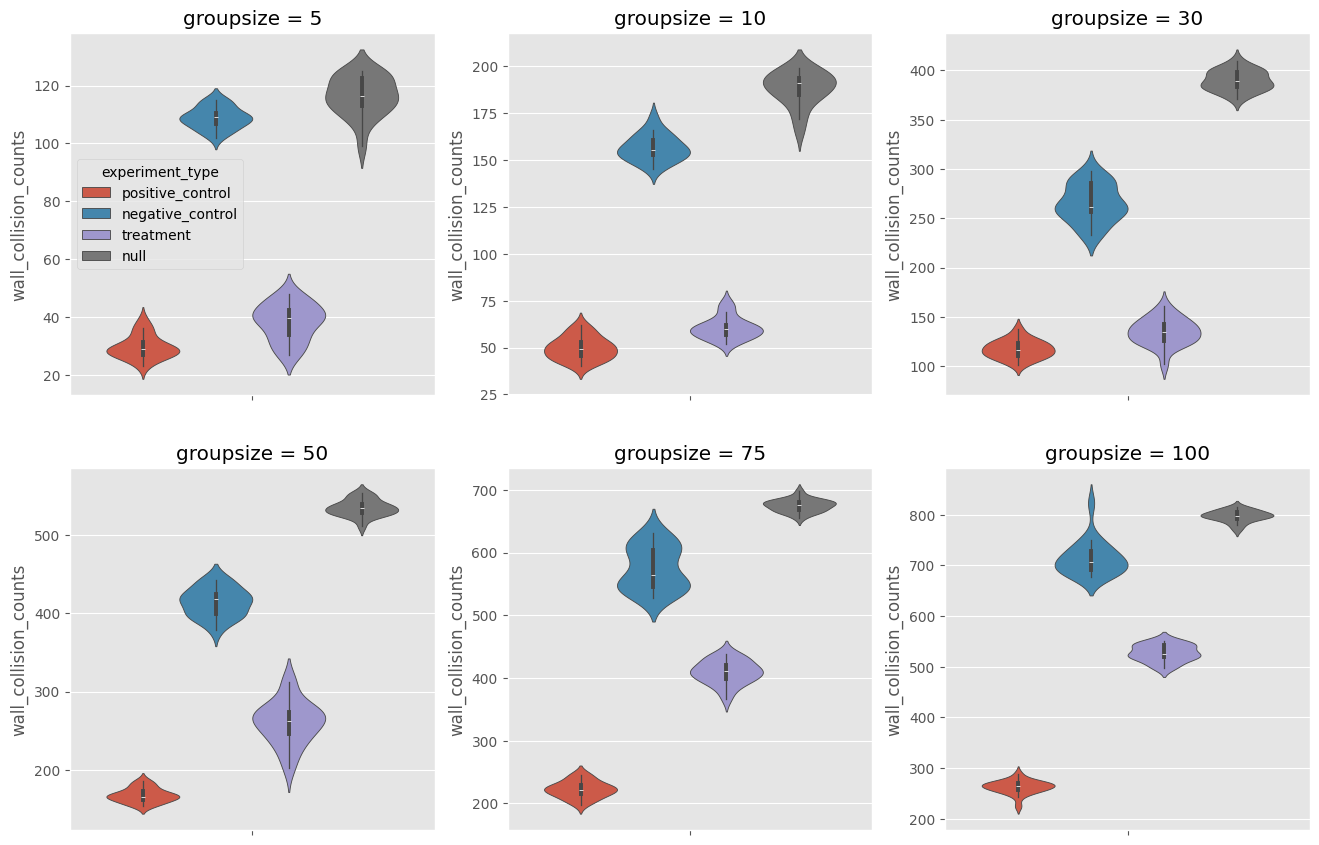

In [ ]:
plt.figure(figsize=(16,16))
for i, group_size in enumerate(group_sizes):
    subset_df = df.loc[(df["group_size"]==group_size)& (df["consistency_type"]=="3/5")]
    plt.subplot(3,3,i+1)
    legend = True if i==0 else False
    sns.violinplot(data=subset_df, hue="experiment_type", y= "wall_collision_counts", legend=legend)
    # plt.ylim(0,30)
    plt.title(f"groupsize = {group_size}")

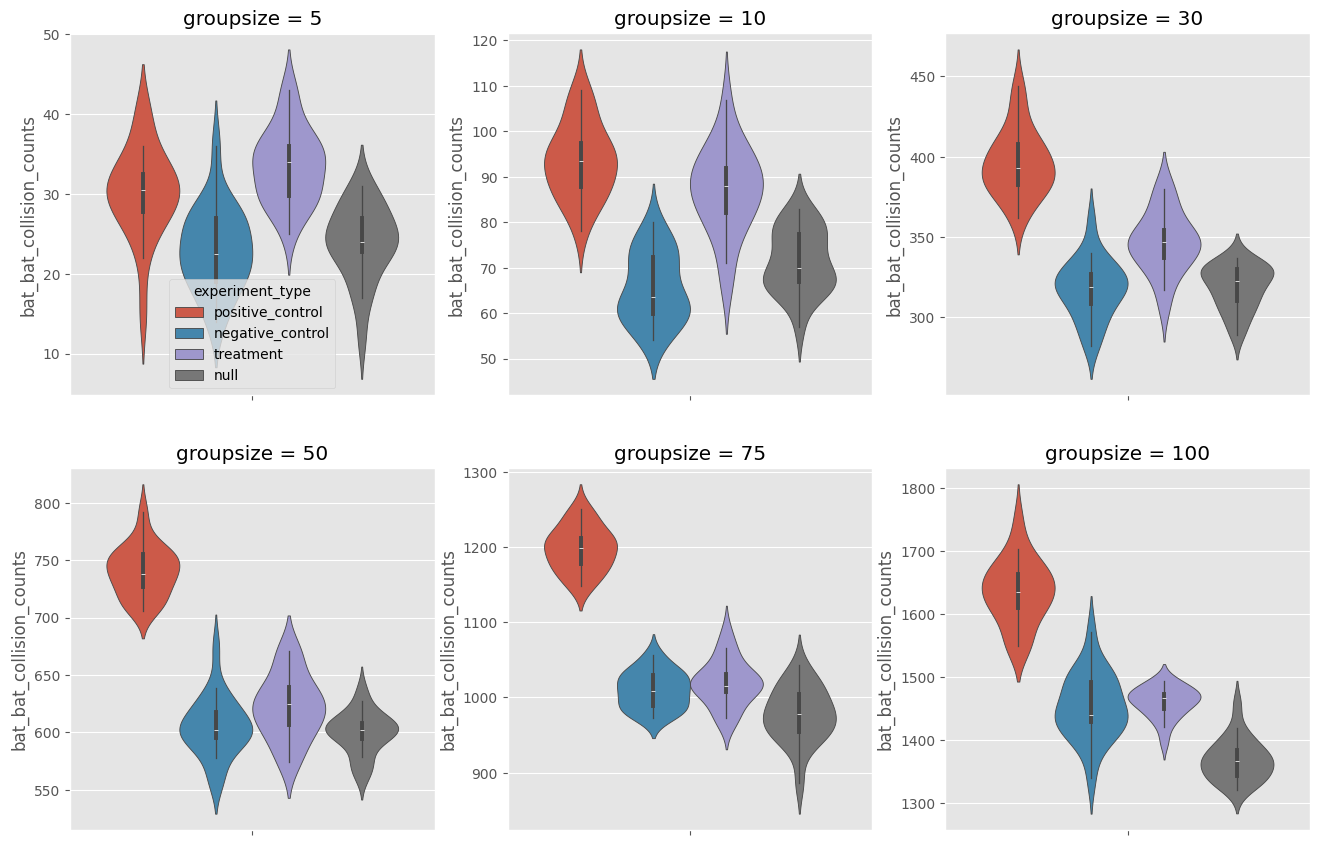

In [ ]:
plt.figure(figsize=(16,16))
for i, group_size in enumerate(group_sizes):
    subset_df = df.loc[(df["group_size"]==group_size)&(df["consistency_type"]=="3/5")]
    plt.subplot(3,3,i+1)
    legend = True if i==0 else False
    sns.violinplot(data=subset_df, hue="experiment_type", y= "bat_bat_collision_counts", legend=legend)
    # plt.ylim(0,30)
    plt.title(f"groupsize = {group_size}")

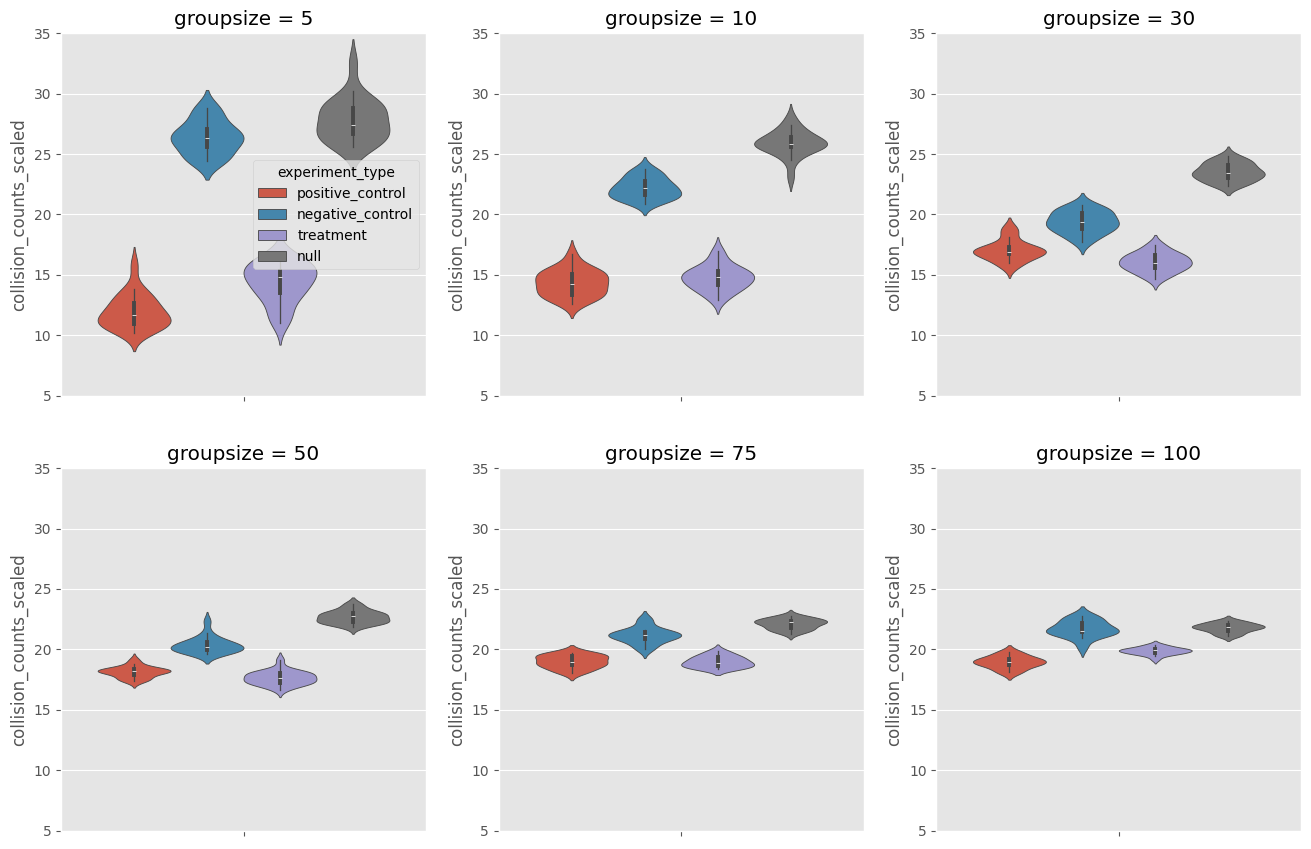

In [ ]:
plt.figure(figsize=(16,16))
for i, group_size in enumerate(group_sizes):
    subset_df = df_copy.loc[(df_copy["group_size"]==group_size)]
    plt.subplot(3,3,i+1)
    legend = True if i==0 else False
    sns.violinplot(data=subset_df, hue="experiment_type", y= "collision_counts_scaled", legend=legend)
    plt.ylim(5,35)
    plt.title(f"groupsize = {group_size}")
    

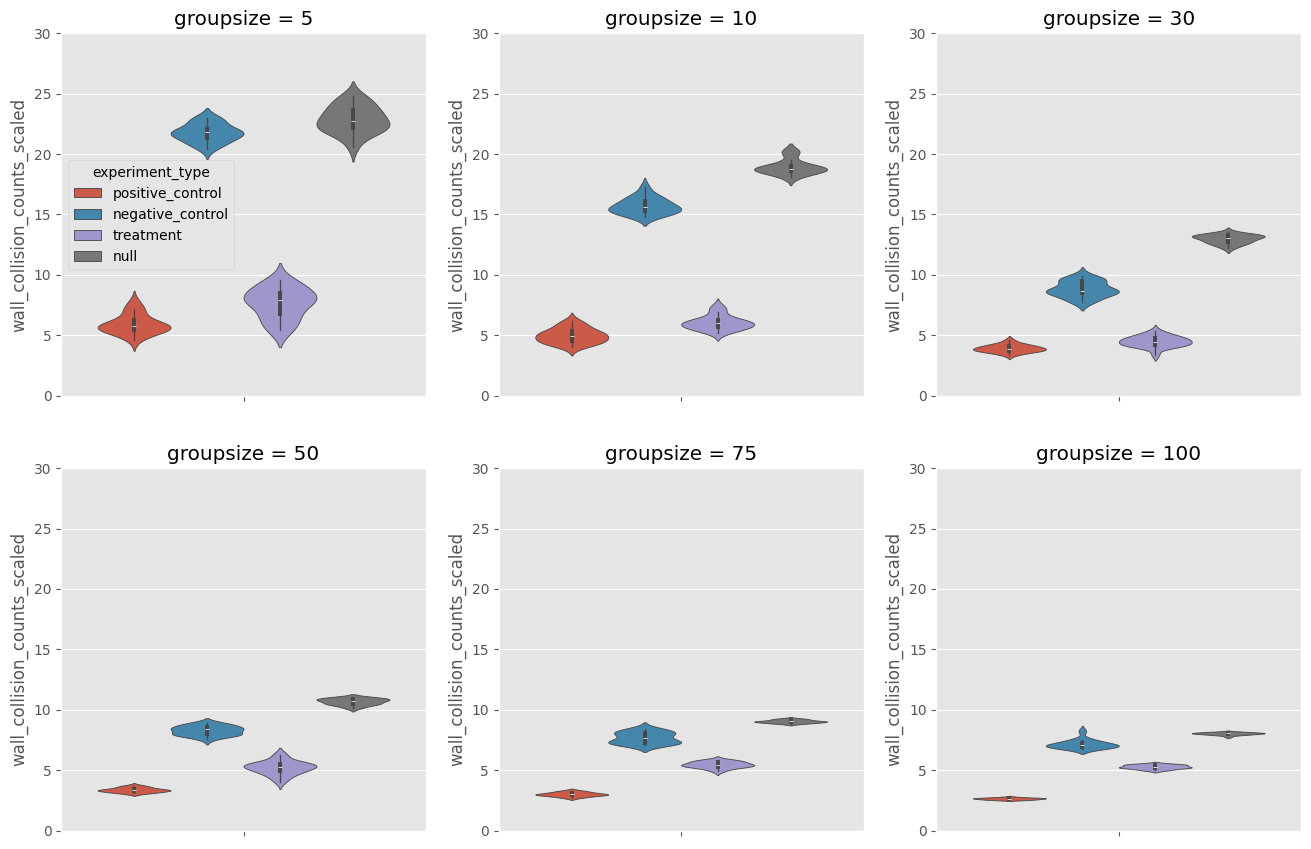

In [ ]:
plt.figure(figsize=(16,16))
for i, group_size in enumerate(group_sizes):
    subset_df = df_copy.loc[(df_copy["group_size"]==group_size)]
    plt.subplot(3,3,i+1)
    legend = True if i==0 else False
    sns.violinplot(data=subset_df, hue="experiment_type", y= "wall_collision_counts_scaled", legend=legend)
    plt.ylim(0,30)
    plt.title(f"groupsize = {group_size}")

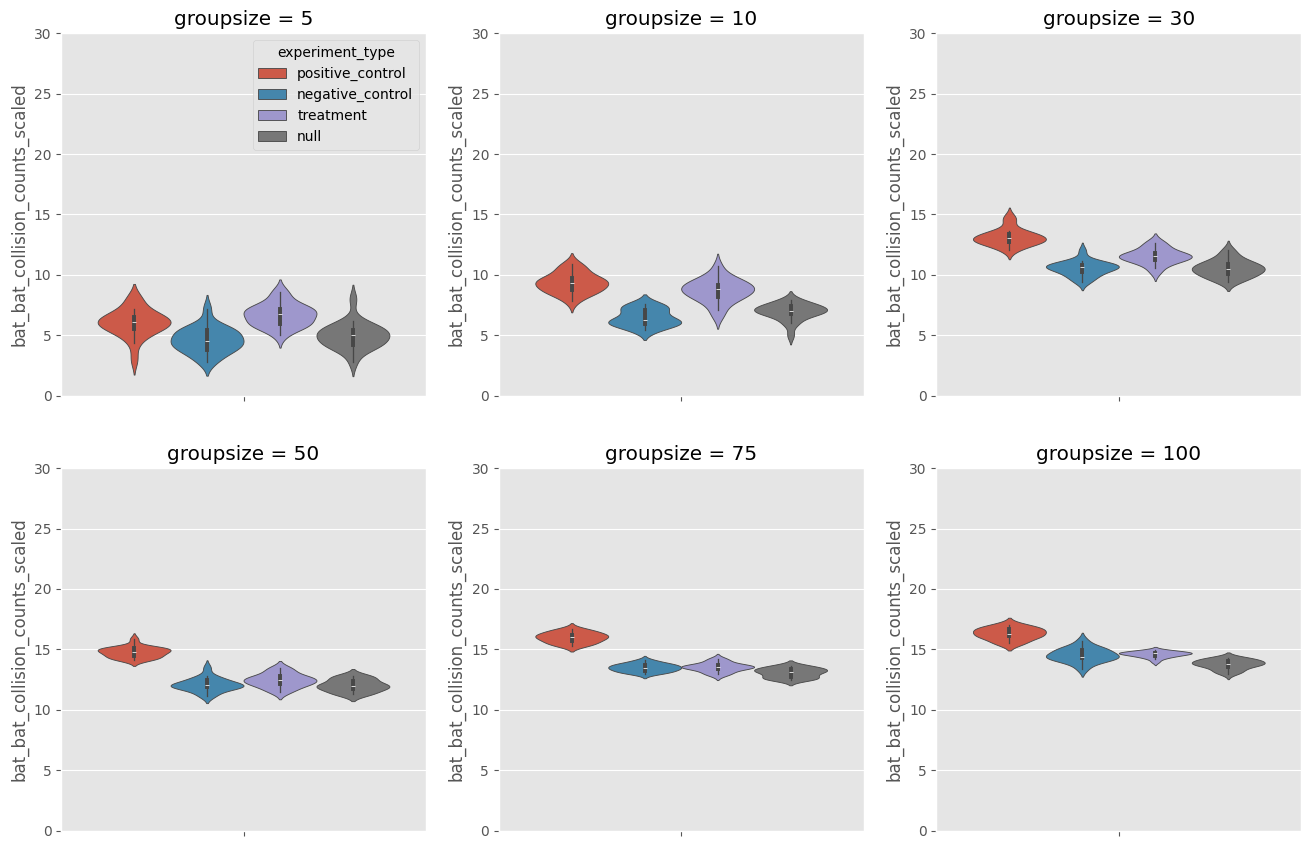

In [ ]:
plt.figure(figsize=(16,16))
for i, group_size in enumerate(group_sizes):
    subset_df = df_copy.loc[(df_copy["group_size"]==group_size)]
    plt.subplot(3,3,i+1)
    legend = True if i==0 else False
    sns.violinplot(data=subset_df, hue="experiment_type", y= "bat_bat_collision_counts_scaled", legend=legend)
    plt.ylim(0,30)
    plt.title(f"groupsize = {group_size}")

Text(0, 0.5, 'collision_counts / group_size')

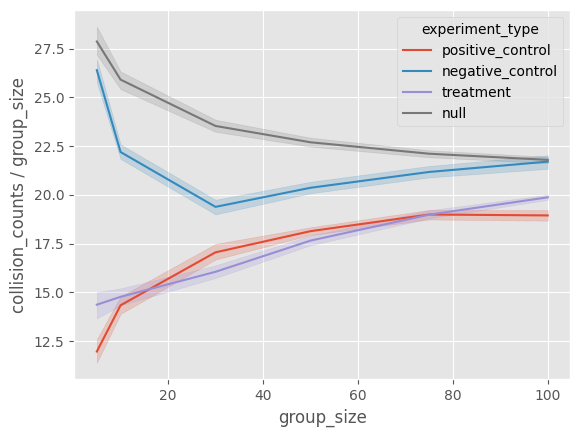

In [ ]:
sns.lineplot(df[~(df_copy["group_size"]==200)], x="group_size", y="collision_counts_scaled", hue="experiment_type")
plt.ylabel("collision_counts / group_size")

Text(0, 0.5, 'wall_collision_counts / group_size')

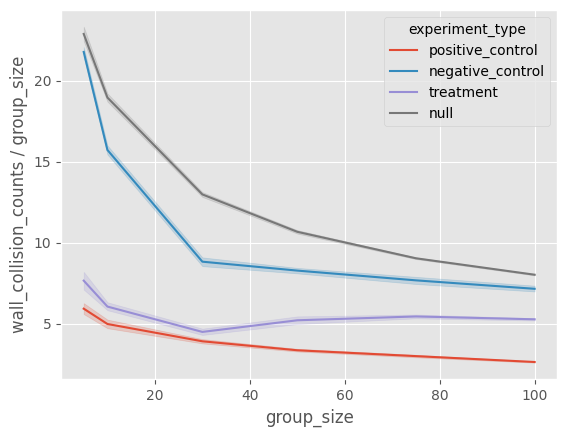

In [ ]:
sns.lineplot(df_copy[~(df_copy["group_size"]==200)], x="group_size", y="wall_collision_counts_scaled", hue="experiment_type")
plt.ylabel("wall_collision_counts / group_size")

Text(0, 0.5, 'bat bat collision_counts / group_size')

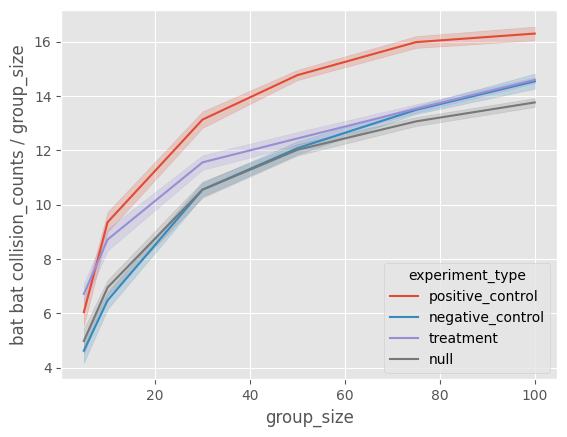

In [ ]:
sns.lineplot(df_copy[~(df_copy["group_size"]==200)], x="group_size", y="bat_bat_collision_counts_scaled", hue="experiment_type")
plt.ylabel("bat bat collision_counts / group_size")

In [ ]:
df

,experiment_type,group_size,iteration,collision_counts,wall_collision_counts,bat_bat_collision_counts,duration,consistency_type,collision_counts_scaled,wall_collision_counts_scaled,bat_bat_collision_counts_scaled
0,positive_control,5,0,59,34,25,30.0,3/5,11.80,6.80,5.00
1,positive_control,5,0,67,21,46,30.0,2/3,13.40,4.20,9.20
2,positive_control,5,1,55,28,27,30.0,3/5,11.00,5.60,5.40
3,positive_control,5,1,51,15,36,30.0,2/3,10.20,3.00,7.20
4,positive_control,5,2,68,36,32,30.0,3/5,13.60,7.20,6.40
...,...,...,...,...,...,...,...,...,...,...,...
955,null,100,17,2133,813,1320,30.0,2/3,21.33,8.13,13.20
956,null,100,18,2156,798,1358,30.0,3/5,21.56,7.98,13.58
957,null,100,18,2156,798,1358,30.0,2/3,21.56,7.98,13.58
958,null,100,19,2220,801,1419,30.0,3/5,22.20,8.01,14.19
